## Supervised Learning Example

In [53]:
# 0) Import relevant libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Hyperparameters

In [54]:
# --- Hyper-parameters USER CONFIGURATION ---
NUM_LAYERS = 1           # how many hidden Dense layers you want
NEURONS_PER_LAYER = 16   # neurons in each hidden layer
EPOCHS = 25              # how many times to iterate over the data

## Create Dataset

In [55]:
# %% 
# 1) Create synthetic ideal-gas data: PV = n R T  =>  T = PV / (n R)
#    plus a little Gaussian noise and a constant offset
np.random.seed(425)
n_samples = 10_000
n = 1.0                   # moles
R = 8.314                 # J/(mol·K)
offset = 10             # constant temperature offset
noise_scale = .2         # stddev of noise

# Random pressures (P) between 1 and 10 Pascals, volumes (V) between 1 and 10 m^3
P = np.random.uniform(1, 100, size=(n_samples, 1))
V = np.random.uniform(1, 100, size=(n_samples, 1))

# Compute true temperature, then add noise
T_true = (P * V) / (n * R)
T = T_true + offset + np.random.normal(scale=noise_scale, size=T_true.shape)

## Split into Test and Train

Typically 80/20 split. You can split differently if you feel the need to.

In [56]:
# Stack inputs and split into train & test
X = np.hstack([P, V])
y = T
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## Initialize Neural Network

In [57]:
def build_model(num_layers, neurons_per_layer, input_dim=2):
    """
    Creates a TF-Keras Sequential model:
      - num_layers hidden layers
      - each with neurons_per_layer units and ReLU activation
      - final output layer has 1 unit (predict T)
    """
    model = models.Sequential()
    # First hidden layer needs input_shape
    model.add(layers.Dense(neurons_per_layer, activation='relu',
                           input_shape=(input_dim,)))
    # Additional hidden layers (if any)
    for _ in range(num_layers - 1):
        model.add(layers.Dense(neurons_per_layer, activation='relu'))
    # Output layer for regression
    model.add(layers.Dense(1, name='temperature_output'))
    # Use default optimizer (Adam) and mean squared error loss
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

model = build_model(NUM_LAYERS, NEURONS_PER_LAYER)


# Show the model summary
model.summary()

/home/rsl/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temperature_output (Dense)      │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

## Train the model

Epoch 1/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 97130.9688 - mae: 219.7876 - val_loss: 56984.6484 - val_mae: 158.6724
Epoch 2/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 32681.0117 - mae: 127.2929 - val_loss: 21391.6621 - val_mae: 112.4875
Epoch 3/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17971.2949 - mae: 108.7622 - val_loss: 17205.7383 - val_mae: 107.5000
Epoch 4/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15477.7461 - mae: 103.5115 - val_loss: 15426.0898 - val_mae: 102.2224
Epoch 5/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13876.0088 - mae: 98.1084 - val_loss: 13934.5654 - val_mae: 97.0654
Epoch 6/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12477.7959 - mae: 92.9122 - val_loss: 12587.8916 - val_mae: 92.0402
Epoch 7/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11201.2764 - mae: 87.9251 - val_loss: 11322.7637 - val_mae: 86.9644
Epoch 8/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10057.7852 - mae: 83.0939 - val_loss

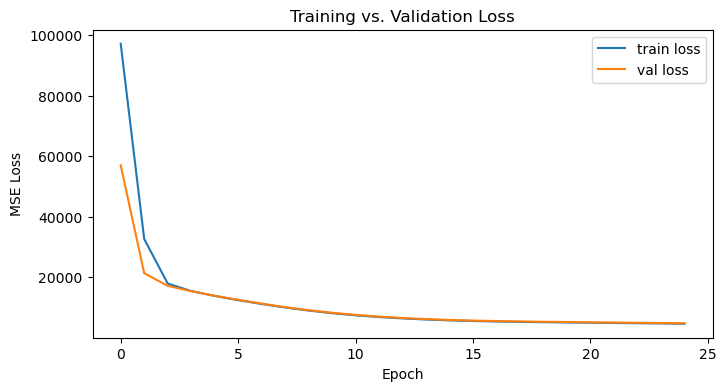

In [58]:

# %% 
# 3) Train for EPOCHS epochs
history = model.fit(
    X_train, y_train,
    validation_split=0.2,  # hold out 20% of train for val
    epochs=EPOCHS,
    batch_size=32,         # default batch size
    verbose=1
)


# Plot training & validation loss over epochs
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.title('Training vs. Validation Loss')
plt.show()

## Visualize Results

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


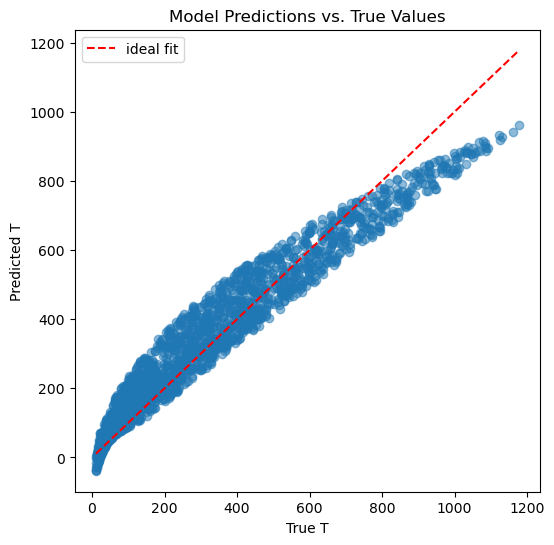

In [59]:


# %% 
# 4) Visualization of training history and predictions



# Scatter true vs. predicted on the test set
y_pred = model.predict(X_test)
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label='ideal fit')
plt.xlabel('True T')
plt.ylabel('Predicted T')
plt.legend()
plt.title('Model Predictions vs. True Values')
plt.show()



## How to hyperparameter search

In [60]:
# %% 
# 5) Notes on hyperparameter search
# To explore different architectures or settings, wrap the build/train steps
# in loops over:
#   - num_layers_list = [1, 2, 3, …]
#   - neurons_list = [8, 16, 32, …]
#   - epochs_list = [20, 50, 100, …]
#
# Example pseudocode:
#
# best_mae = np.inf
# for nl in num_layers_list:
#     for nn in neurons_list:
#         for ep in epochs_list:
#             m = build_model(nl, nn)
#             h = m.fit(X_train, y_train, epochs=ep, validation_split=0.2, verbose=0)
#             mae = m.evaluate(X_val, y_val, verbose=0)[1]
#             if mae < best_mae:
#                 best_mae = mae
#                 best_params = (nl, nn, ep)
#
# You can also integrate scikit-learn’s GridSearchCV with a KerasRegressor wrapper.


## More advanced Version.

Try playing with the number of data points needed. (10 samples per each integer currently. Go down to 0.1 sample per integer).  


Also, all input and output values are scaled between -1 and +1. THe model is trained, and then rescaled.

/home/rsl/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ T_out (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0939 - mae: 0.1647 - val_loss: 0.0013 - val_mae: 0.0289 - learning_rate: 0.0010
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.2242e-04 - mae: 0.0234 - val_loss: 6.3594e-04 - val_mae: 0.0191 - learning_rate: 0.0010
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.0430e-04 - mae: 0.0168 - val_loss: 4.1267e-04 - val_mae: 0.0148 - learning_rate: 0.0010
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.2149e-04 - mae: 0.0130 - val_loss: 2.8529e-04 - val_mae: 0.0126 - learning_rate: 0.0010
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.3177e-04 - mae: 0.0110 - val_loss: 2.2226e-04 - val_mae: 0.0102 - learning_rate: 0.0010
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.6515e-04 - mae: 0.0091 - val_loss: 1.4241e-04 - val_mae: 0.0084 - learning_rate: 0.0010
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2739e-04 - mae: 0.0079 - val_loss: 1.0865e-04 

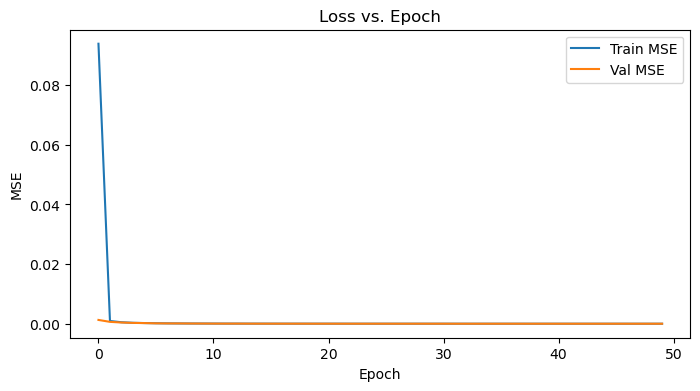

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


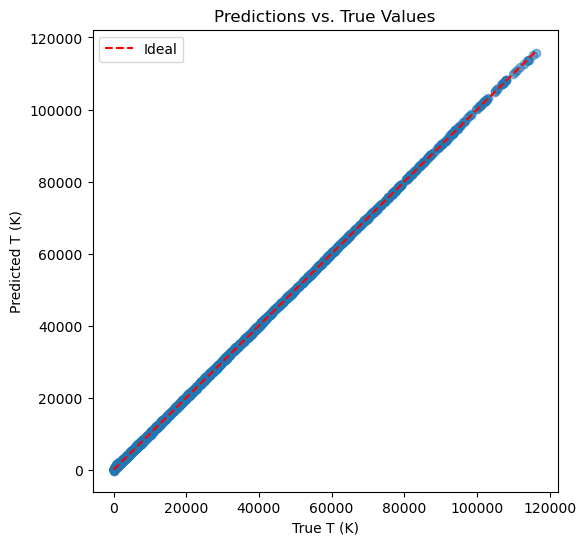

In [63]:
# %% 
# 1) Imports
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

# %% 
# 2) User configuration
NUM_LAYERS       = 2       # number of hidden layers
NEURONS_PER_LAYER= 32      # units per hidden layer
EPOCHS           = 50     # training epochs
N_SAMPLES        = 10_000   # total data points
P_MIN, P_MAX     = 1, 1000 # pressure range
V_MIN, V_MAX     = 1, 1000 # volume range
OFFSET           = 5.0     # constant offset added to T
NOISE_STD        = 0.5     # Gaussian noise on T

# %% 
# 3) Generate synthetic dataset
np.random.seed(42)
n, R = 1.0, 8.314  # PV = nRT

P = np.random.uniform(P_MIN, P_MAX, (N_SAMPLES,1))
V = np.random.uniform(V_MIN, V_MAX, (N_SAMPLES,1))
T_true = (P * V) / (n * R)
T = T_true + OFFSET + np.random.normal(scale=NOISE_STD, size=T_true.shape)

# train/test split
X = np.hstack([P, V])
y = T
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# %% 
# 4) Scale inputs & outputs to [–1,1]
scaler_X = MinMaxScaler(feature_range=(-1,1))
X_train_s = scaler_X.fit_transform(X_train)
X_test_s  = scaler_X.transform(X_test)

scaler_y = MinMaxScaler(feature_range=(-1,1))
y_train_s = scaler_y.fit_transform(y_train)
y_test_s  = scaler_y.transform(y_test)

# %% 
# 5) Model factory
def build_model(num_layers, neurons, input_dim=2):
    """
    - num_layers hidden ReLU layers
    - 'neurons' units each
    - 1-unit linear output
    """
    m = models.Sequential()
    m.add(layers.Dense(neurons, activation='relu',
                       input_shape=(input_dim,)))
    for _ in range(num_layers-1):
        m.add(layers.Dense(neurons, activation='relu'))
    m.add(layers.Dense(1, name='T_out'))
    m.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return m

model = build_model(NUM_LAYERS, NEURONS_PER_LAYER)
model.summary()

# %% 
# 6) Train with LR scheduler
lr_cb = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6)

history = model.fit(
    X_train_s, y_train_s,
    validation_split=0.2,
    epochs=EPOCHS,
    batch_size=32,
    callbacks=[lr_cb],
    verbose=1
)

# %% 
# 7) Plot training history
plt.figure(figsize=(8,4))
plt.plot(history.history['loss'], label='Train MSE')
plt.plot(history.history['val_loss'], label='Val MSE')
plt.xlabel('Epoch'); plt.ylabel('MSE')
plt.legend(); plt.title('Loss vs. Epoch')
plt.show()

# %% 
# 8) Predict & inverse‐scale
y_pred_s = model.predict(X_test_s)
y_pred   = scaler_y.inverse_transform(y_pred_s)

# %% 
# 9) Scatter true vs. predicted
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', label='Ideal')
plt.xlabel('True T (K)')
plt.ylabel('Predicted T (K)')
plt.legend(); plt.title('Predictions vs. True Values')
plt.show()
